<a href="https://colab.research.google.com/github/Shihori/AI/blob/main/molNW_sec6_cnn_230529_12_11_23_ipynb_CPP_12_22_23_ipynb_SPINK1val.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/molNW/
%ls -a

Mounted at /content/drive
/content/drive/MyDrive/molNW
8-13-21-DataRobotEMT-DP100pic/  model.pt
cell_images/                    molNW_sec6_cnn_230529_12_11_23_ipynb_copy.ipynb
coronapathogenesis/             SPINK1GeneralCancerPathway-activity-plots/
model_finetuning.pt


In [2]:
!pip install pytorch-gradcam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 33.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pytorch-gradcam: filename=pytorch_gradcam-0.2.1-py3-none-any.whl size=5249 sha256=bb07453429bed97d9e3cef5c5ae0d429371a33c16ffef8752a3fd7ceee5fce2d
  Stored in directory: /root/.cache/pip/wheels/b3/37/60/ab0eb271797fc9bf2a8b6edd8e550f2ee0857031e4cc0e2509
Successfully built pytorch-gradcam


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import os
import scipy
import random
from tqdm import tqdm
import glob

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

import torch
from torch import nn
from torch.utils.data import DataLoader
import torch.optim as optim

import torchvision
from torchvision import models
from torchvision import datasets
from torchvision import transforms as transforms

from gradcam.utils import visualize_cam
from gradcam import GradCAM, GradCAMpp


In [4]:
path = "/content/drive/MyDrive/molNW"
im_fd = "/SPINK1GeneralCancerPathway-activity-plots/"

/content/drive/MyDrive/molNW/SPINK1GeneralCancerPathway-activity-plots/inactivated/8-23-23-12- hepatocellular carcinoma (LIHC) liver IFN beta 1a 25919-SPINK1-DR50.jpg


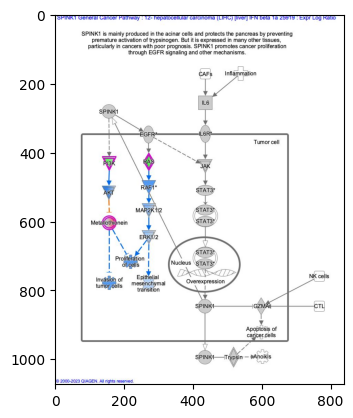

In [5]:
folder = ['inactivated','activated']
file0 = glob.glob(path + im_fd + folder[0] +"/*.jpg")[0]
print(file0)
image = Image.open(file0)
plt.imshow(image)

In [6]:
np.array(image)

array([[[255, 248, 235],
        [255, 255, 243],
        [255, 253, 243],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 251, 249],
        [255, 253, 250],
        [254, 249, 245],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 250, 255],
        [255, 250, 255],
        [255, 252, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 252, 255],
        [253, 250, 255],
        [251, 252, 246],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[249, 244, 251],
        [255, 254, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 254, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu" # Get cpu or gpu device for training.
print(f"Using {device} device")

Using cuda device


In [8]:
image_size = 128;

In [9]:
SEED = 42

def seed_fix(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms = True
    torch.backends.cudnn.deterministic = True

    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_fix(SEED)
generator = torch.Generator()
generator.manual_seed(SEED)

In [10]:
folder = ['inactivated','activated']
X = [];
y = [];
usenumber = 50
for i,folname in enumerate(folder):
    files1 = glob.glob(path + im_fd + folname +"/*.jpg");
    f_number = len(files1)
    files1, files2=torch.utils.data.random_split(files1,[usenumber,f_number - usenumber])
    for j, file in enumerate(tqdm(files1)):
        outcome = i
        image = Image.open(file)
        image = image.convert("RGB")
        image = image.resize((image_size, image_size))
        data = np.asarray(image)
        X.append(data);
        y.append(outcome)

100%|██████████| 50/50 [00:19<00:00,  2.61it/s]


In [11]:

X = np.array(X).astype(np.float32).transpose(0,3,1,2)/255
y = np.array(y)

In [12]:
Nall = X.shape[0]

In [13]:
tensor_X = torch.tensor(X, dtype=torch.float32)
tensor_y = torch.tensor(y, dtype=torch.int64)

In [14]:
dataset = torch.utils.data.TensorDataset(tensor_X,tensor_y)
n_train = int(Nall * 0.7)
n_val = int(Nall * 0.2)
n_test = Nall - n_train - n_val
train_x, val_x, test_x = torch.utils.data.random_split(dataset, [n_train, n_val,n_test])
print("train =",n_train,",validation =",n_val,",Test =",n_test)

train = 70 ,validation = 20 ,Test = 10


In [15]:
batch_size = 64
train_dataloader = DataLoader(train_x, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_x,   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(test_x,  batch_size=1, shuffle=False)

In [16]:
class CNN(nn.Module):
    def __init__(self, input_shape=(3,128,128),output_size=2):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(in_channels=input_shape[0], out_channels=16, kernel_size=3, padding='same'),nn.ReLU(),nn.MaxPool2d(2,2))
        self.conv2 = nn.Sequential(nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding='same'),nn.ReLU(),nn.MaxPool2d(2,2))
        self.conv3 = nn.Sequential(nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding='same'),nn.ReLU(),nn.MaxPool2d(2,2))
        self.conv4 = nn.Sequential(nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),nn.ReLU(),nn.MaxPool2d(2,2))
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.2)
        self.CNN_outshape = self._get_conv_output(input_shape)
        self.linear = nn.Linear(self.CNN_outshape, output_size)
    def _get_conv_output(self, shape):
        bs = 1
        dummy_x = torch.empty(bs, *shape)
        x = self._forward_features(dummy_x)
        CNN_outshape = x.flatten(1).size(1)
        return CNN_outshape
    def _forward_features(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.dropout(x)
        x = self.flatten(x)
        return x
    def forward(self, x):
        x = self._forward_features(x)
        x = self.linear(x.flatten(1))
        return x
model = CNN().to(device)
print(model)

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=4096, out_features=2, bias=True)
)


In [17]:
transform = transforms.Compose([
    transforms.RandomResizedCrop((image_size,image_size)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.RandomVerticalFlip(p=0.4),
    transforms.RandomRotation(degrees=[-7.5, 7.5])
    ]
) #Data augumentation

In [18]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay= 0.005)

def train(train_loader): #Training
    model.train()
    running_loss = 0
    correct = 0
    total = len(train_loader.dataset)
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        #data augumentation
        #images = transform(images)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predicted = outputs.max(1, keepdim=True)[1]
        labels = labels.view_as(predicted)
        correct += predicted.eq(labels).sum().item()
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    return train_loss, train_acc

def valid(test_loader): #Validation
    model.eval()
    running_loss = 0
    correct = 0
    total = len(test_loader.dataset)
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predicted = outputs.max(1, keepdim=True)[1]
            labels = labels.view_as(predicted)
            correct += predicted.eq(labels).sum().item()
    val_loss = running_loss / len(test_loader)
    val_acc = correct / total
    return val_loss, val_acc

acc_list = []
loss_list = []
val_loss_list = []
val_acc_list = []

In [19]:
nepoch = 300

#Fitting
for epoch in range(nepoch):
    loss, acc = train(train_dataloader)
    val_loss, val_acc = valid(val_dataloader)
    print('epoch %d, loss: %.4f acc: %.4f val_loss: %.4f val_acc: %.4f' % (epoch, loss,acc, val_loss, val_acc))
    loss_list.append(loss)
    acc_list.append(acc)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

epoch 0, loss: 0.6908 acc: 0.5714 val_loss: 0.6926 val_acc: 0.5500
epoch 1, loss: 0.6923 acc: 0.5286 val_loss: 0.6927 val_acc: 0.5500
epoch 2, loss: 0.6912 acc: 0.6000 val_loss: 0.6929 val_acc: 0.5500
epoch 3, loss: 0.6945 acc: 0.5286 val_loss: 0.6932 val_acc: 0.4500
epoch 4, loss: 0.6944 acc: 0.4143 val_loss: 0.6932 val_acc: 0.4500
epoch 5, loss: 0.6932 acc: 0.4857 val_loss: 0.6930 val_acc: 0.7500
epoch 6, loss: 0.6932 acc: 0.4714 val_loss: 0.6929 val_acc: 0.5500
epoch 7, loss: 0.6933 acc: 0.5286 val_loss: 0.6929 val_acc: 0.5500
epoch 8, loss: 0.6948 acc: 0.5429 val_loss: 0.6927 val_acc: 0.5500
epoch 9, loss: 0.6880 acc: 0.6000 val_loss: 0.6925 val_acc: 0.5500
epoch 10, loss: 0.6926 acc: 0.5143 val_loss: 0.6923 val_acc: 0.5500
epoch 11, loss: 0.6939 acc: 0.5714 val_loss: 0.6922 val_acc: 0.5500
epoch 12, loss: 0.6954 acc: 0.5714 val_loss: 0.6922 val_acc: 0.5500
epoch 13, loss: 0.6951 acc: 0.5143 val_loss: 0.6926 val_acc: 0.5500
epoch 14, loss: 0.6947 acc: 0.5714 val_loss: 0.6930 val_ac

In [20]:
torch.save(model, 'model.pt')

In [21]:
model = torch.load('model.pt', weights_only=False)

Accuracy : 45.0 %


Text(0, 0.5, 'acc')

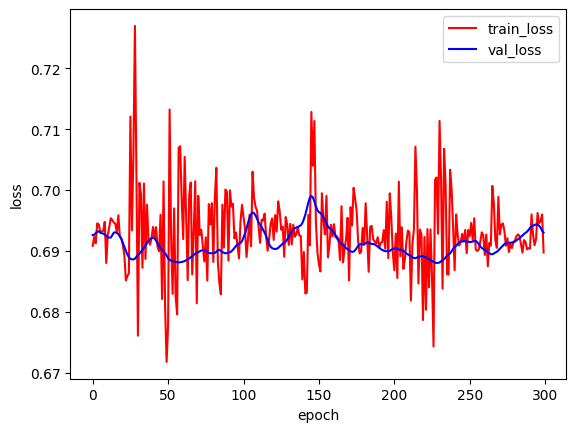

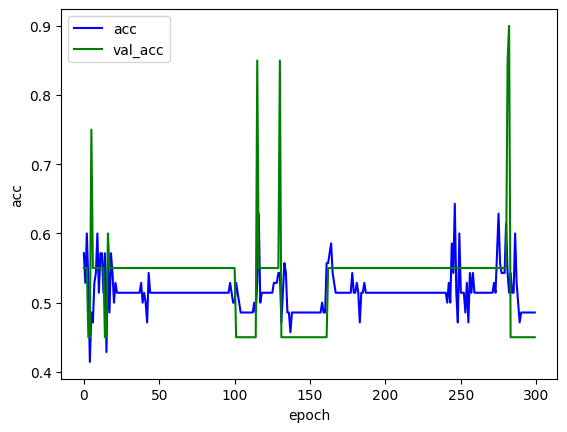

In [22]:
print('Accuracy :',val_acc_list[-1]*100, '%')

plt.plot(range(nepoch), loss_list, 'r-', label='train_loss')
plt.plot(range(nepoch), val_loss_list, 'b-', label='val_loss')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')

plt.figure()
plt.plot(range(nepoch), acc_list, 'b-', label='acc')
plt.plot(range(nepoch), val_acc_list, 'g-', label='val_acc')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('acc')

In [23]:
def test(test_loader):
    prob = []
    pred = []
    true = []
    model.eval()
    running_loss = 0
    correct = 0
    total = len(test_loader.dataset)
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            lprob, predicted = outputs.max(1, keepdim=True)
            labels = labels.view_as(predicted)
            correct += predicted.eq(labels).sum().item()
            prob = np.append(prob, scipy.special.expit(torch.Tensor.numpy(outputs[:,1].to('cpu'))))
            pred = np.append(pred, torch.Tensor.numpy(predicted.to('cpu')))
            true = np.append(true, torch.Tensor.numpy(labels.to('cpu')))
    return prob, pred, true

prob, pred, true,  = test(test_dataloader)


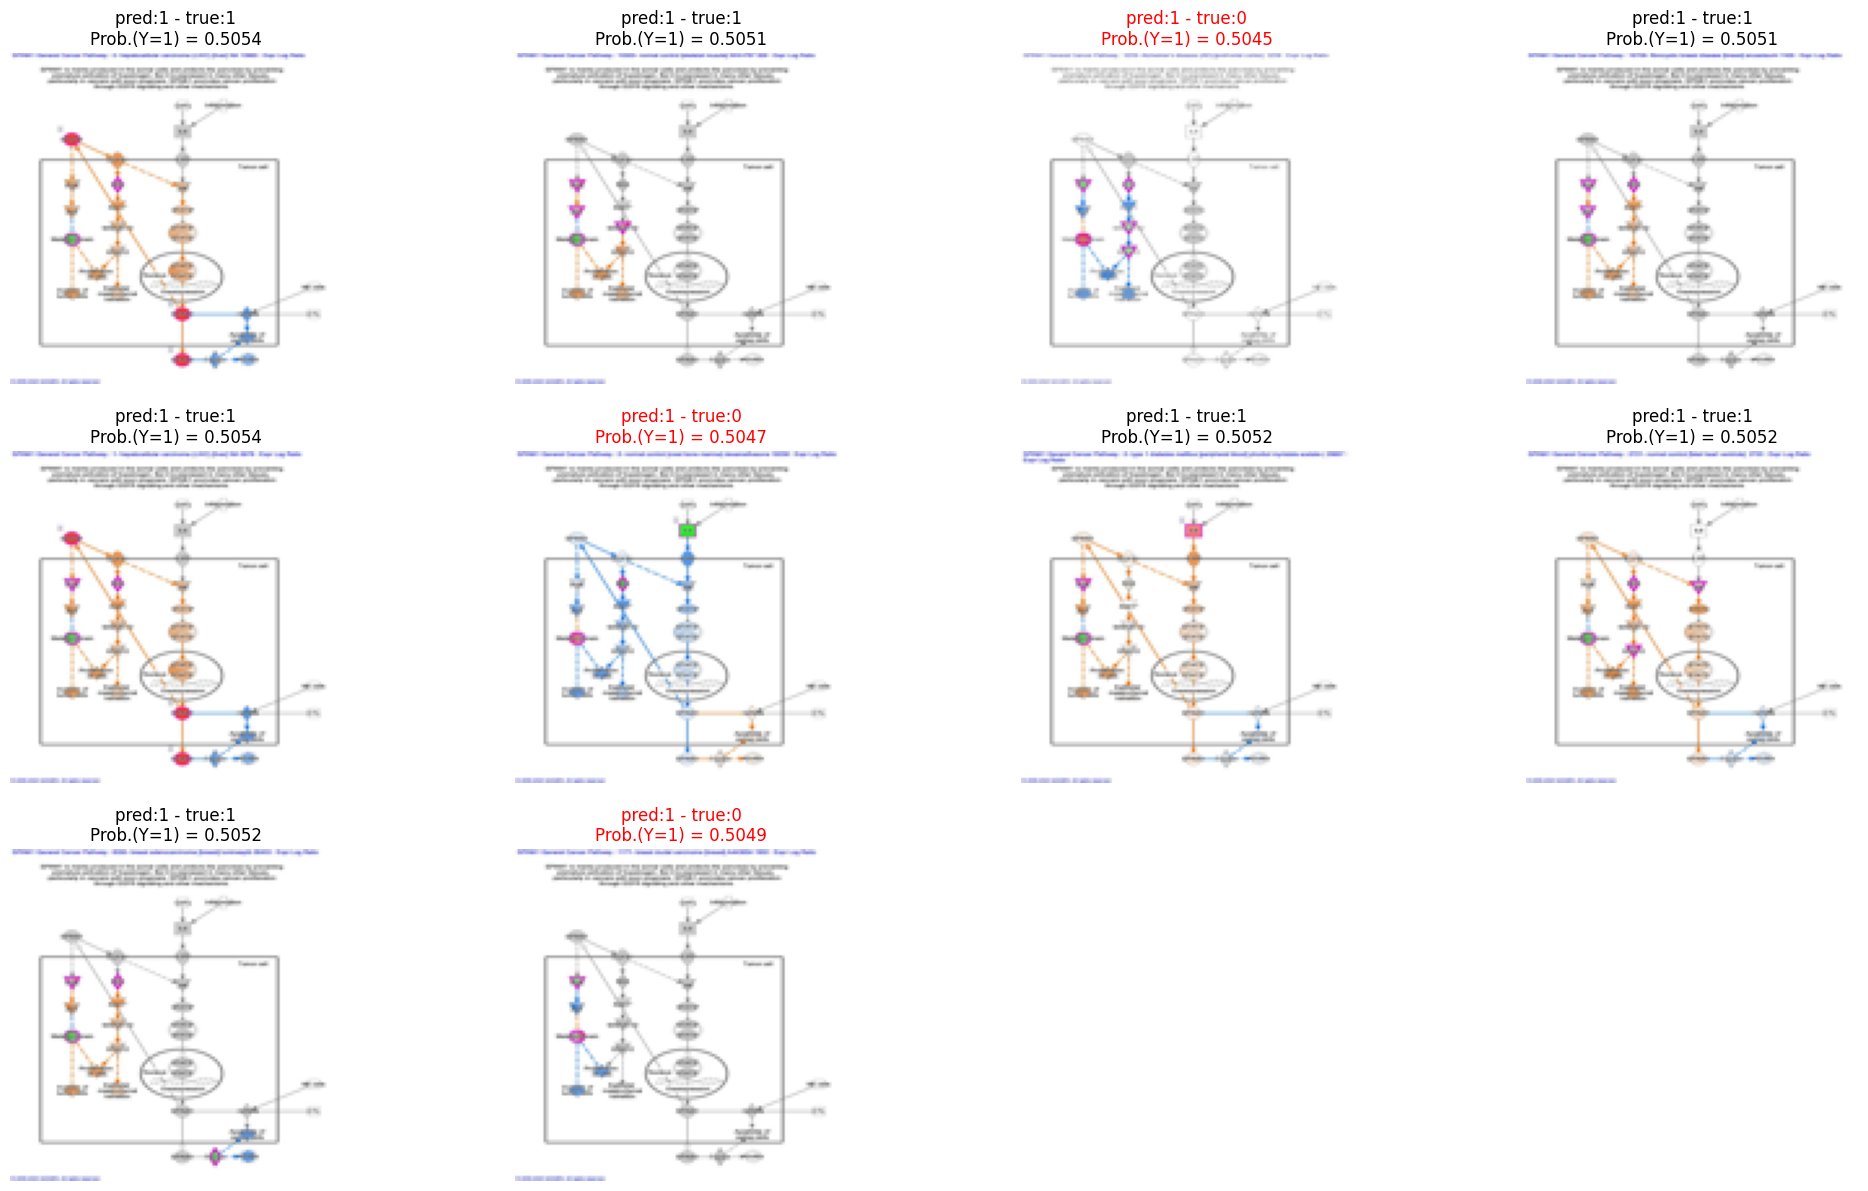

In [24]:
# Output the images, predicted labels, ground truth labels, and prediction probabilities for the test datatest
plt.figure(figsize = (25, 25))
for i in range(n_test): # Iterate only up to the number of test samples
    plt.subplot(5, 4, i + 1)
    plt.axis("off")
    if pred[i] == true[i]:
        plt.title("pred:"+str(pred[i].astype(np.uint8))+' - '+"true:"+str(true[i].astype(np.uint8))+'\n'+'Prob.(Y=1) = %.4f' % (prob[i]))
    else:
        plt.title("pred:"+str(pred[i].astype(np.uint8))+' - '+"true:"+str(true[i].astype(np.uint8))+'\n'+'Prob.(Y=1) = %.4f' % (prob[i]), color = "red")

    tmp = test_x[i][0].to('cpu').detach().numpy().copy()
    tmp = tmp.transpose(1, 2, 0)
    img_pil = Image.fromarray((tmp*255).astype(np.uint8))
    plt.imshow(img_pil)

In [25]:
#Summarize correct and incorrect answers in a 2×2 matrix
cmat = confusion_matrix(true, pred)
print(cmat)

#Calculation of Sensitivity and Specificity
tn, fp, fn, tp = cmat.flatten()

acc = round((tp+tn)/(tp+tn+fp+fn),4)
sen = round(tp/(tp+fn),4)
spe = round(tn/(tn+fp),4)
ppv = round(tp/(tp+fp),4)
npv = round(tn/(tn+fn),4)
print("acc=",acc,"sen=",sen," ,spe=",spe," ,ppv=",ppv," ,npv=",npv)



[[0 3]
 [0 7]]
acc= 0.7 sen= 1.0  ,spe= 0.0  ,ppv= 0.7  ,npv= nan


/tmp/ipykernel_1860/3193850801.py:12: RuntimeWarning: invalid value encountered in scalar divide
  npv = round(tn/(tn+fn),4)


Cutoff-value: 0.5051 Sensitivity: 1.0 Specificity:  1.0


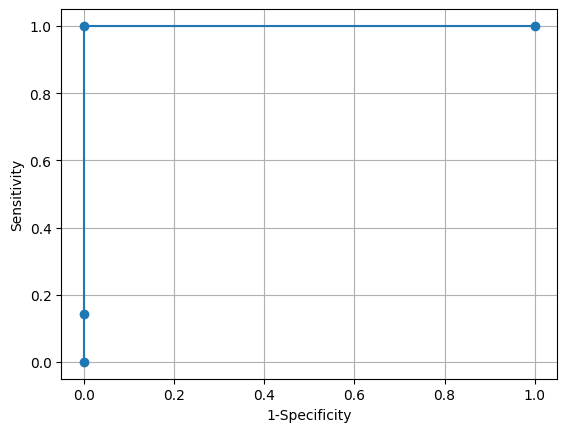

In [26]:
#ROC curve

fpr, tpr, thresholds = roc_curve(true, prob)
plt.plot(fpr, tpr, marker='o')
plt.xlabel('1-Specificity')
plt.ylabel('Sensitivity')
plt.grid()
#plt.savefig(path+'/roc_curve.png')

Youden_index = tpr-fpr
index = np.where(Youden_index==max(Youden_index))[0][0]

cutoff = thresholds[index]
sensitivity = tpr[index]
specificity = 1 - fpr[index]
print("Cutoff-value:",round(cutoff,4),"Sensitivity:",round(sensitivity,4),"Specificity: ",round(specificity,4))




In [27]:
#!pip install grad-cam -q
#!conda install grad-cam

Grad-CAM

In [28]:
# Grad-CAM

In [29]:
#Loading
model = torch.load('model.pt', weights_only=False)
model.eval()

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=4096, out_features=2, bias=True)
)

In [30]:
print(model)

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=4096, out_features=2, bias=True)
)


In [31]:
target_layer = model.conv4[1]

In [32]:
gradcam = GradCAM(model, target_layer)

/usr/local/lib/python3.12/dist-packages/gradcam/gradcam.py:81: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  saliency_map = F.upsample(saliency_map, size=(h, w), mode='bilinear', align_corners=False)


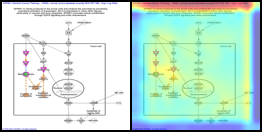

In [33]:
image_number = 1
torch_img = torch.tensor(np.expand_dims(test_x[image_number][0], 0)).to(device) #Image in Torch
images = []
mask, _ = gradcam(torch_img)
heatmap, result = visualize_cam(mask, torch_img)
image0 = torch.squeeze(torch_img,dim=0)
images.extend([image0.cpu(), result])
grid_image = torchvision.utils.make_grid(images, nrow=2)
transforms.ToPILImage()(grid_image)

Finetuning

In [34]:
model = models.vgg16(pretrained=True)
model.classifier[6] = nn.Linear(in_features=4096,out_features=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 172MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [35]:
params_to_update = []
update_param_names = ['classifier.6.weight', 'classifier.6.bias']
for name, param in model.named_parameters():
    if name in update_param_names:
        param.requires_grad = True
        params_to_update.append(param)
        print(name)
    else:
        param.requires_grad = False

classifier.6.weight
classifier.6.bias


In [36]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=params_to_update, lr=0.001, momentum=0.9)



def train(train_loader):
    model.train()
    running_loss = 0
    correct = 0
    total = len(train_loader.dataset)

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = outputs.max(1, keepdim=True)[1]
        labels = labels.view_as(predicted)
        correct += predicted.eq(labels).sum().item()


    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    return train_loss, train_acc



def valid( test_loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = len(test_loader.dataset)
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predicted = outputs.max(1, keepdim=True)[1]
            labels = labels.view_as(predicted)
            correct += predicted.eq(labels).sum().item()
            #break

    val_loss = running_loss / len(test_loader)
    val_acc = correct / total
    return val_loss, val_acc

acc_list = []
loss_list = []
val_loss_list = []
val_acc_list = []


In [37]:
nepoch = 50

for epoch in range(nepoch):

    if(epoch > 0):
        loss, acc = train(train_dataloader)
    else:
        loss, acc = valid(train_dataloader)

    val_loss, val_acc = valid(val_dataloader)
    print('epoch %d, loss: %.4f acc: %.4f val_loss: %.4f val_acc: %.4f' % (epoch, loss,acc, val_loss, val_acc))
    loss_list.append(loss)
    acc_list.append(acc)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

epoch 0, loss: 0.7662 acc: 0.4857 val_loss: 0.7006 val_acc: 0.4500
epoch 1, loss: 0.7502 acc: 0.5286 val_loss: 0.6178 val_acc: 0.8500
epoch 2, loss: 0.7059 acc: 0.5571 val_loss: 0.5491 val_acc: 0.8500
epoch 3, loss: 0.6579 acc: 0.5714 val_loss: 0.4757 val_acc: 0.9000
epoch 4, loss: 0.6023 acc: 0.7143 val_loss: 0.5078 val_acc: 0.5500
epoch 5, loss: 0.5399 acc: 0.6000 val_loss: 0.5547 val_acc: 0.5500
epoch 6, loss: 0.4965 acc: 0.5571 val_loss: 0.3404 val_acc: 0.8500
epoch 7, loss: 0.3835 acc: 0.8429 val_loss: 0.3784 val_acc: 0.8500
epoch 8, loss: 0.8000 acc: 0.7714 val_loss: 0.3709 val_acc: 0.8500
epoch 9, loss: 0.4265 acc: 0.7571 val_loss: 0.2605 val_acc: 0.9000
epoch 10, loss: 0.3292 acc: 0.8429 val_loss: 0.2661 val_acc: 0.8500
epoch 11, loss: 0.4233 acc: 0.8286 val_loss: 0.2757 val_acc: 0.8500
epoch 12, loss: 0.3410 acc: 0.8429 val_loss: 0.2254 val_acc: 0.8500
epoch 13, loss: 0.2114 acc: 0.9000 val_loss: 0.1874 val_acc: 0.9500
epoch 14, loss: 0.2170 acc: 0.8571 val_loss: 0.1815 val_ac

In [38]:
torch.save(model, 'model_finetuning.pt')


Accuracy :  95.0 %


Text(0, 0.5, 'acc')

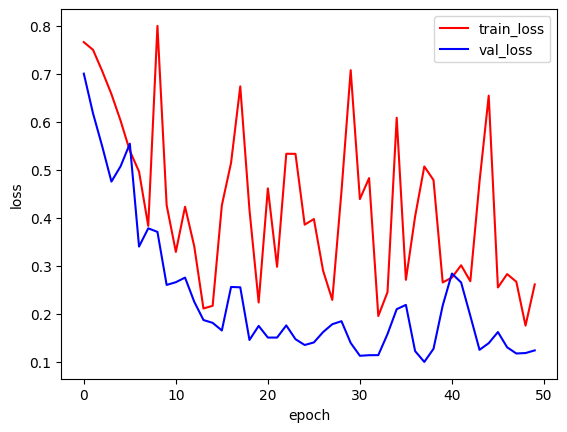

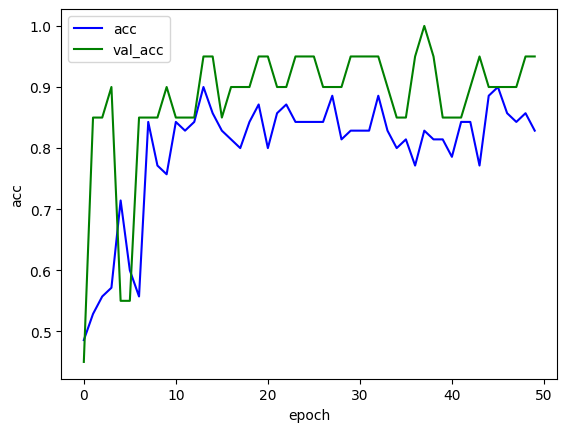

In [39]:
print('Accuracy : ',val_acc_list[-1]*100, '%')

plt.plot(range(nepoch), loss_list, 'r-', label='train_loss')
plt.plot(range(nepoch), val_loss_list, 'b-', label='val_loss')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')

plt.figure()
plt.plot(range(nepoch), acc_list, 'b-', label='acc')
plt.plot(range(nepoch), val_acc_list, 'g-', label='val_acc')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('acc')

In [40]:
#For Test
def test(test_loader):
    prob = []
    pred = []
    true = []
    model.eval()
    running_loss = 0
    correct = 0
    total = len(test_loader.dataset)
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            lprob, predicted = outputs.max(1, keepdim=True)
            labels = labels.view_as(predicted)
            correct += predicted.eq(labels).sum().item()
            prob = np.append(prob, scipy.special.expit(torch.Tensor.numpy(outputs[:,1].to('cpu'))))
            pred = np.append(pred, torch.Tensor.numpy(predicted.to('cpu')))
            true = np.append(true, torch.Tensor.numpy(labels.to('cpu')))
    return prob, pred, true

prob, pred, true,  = test(test_dataloader)


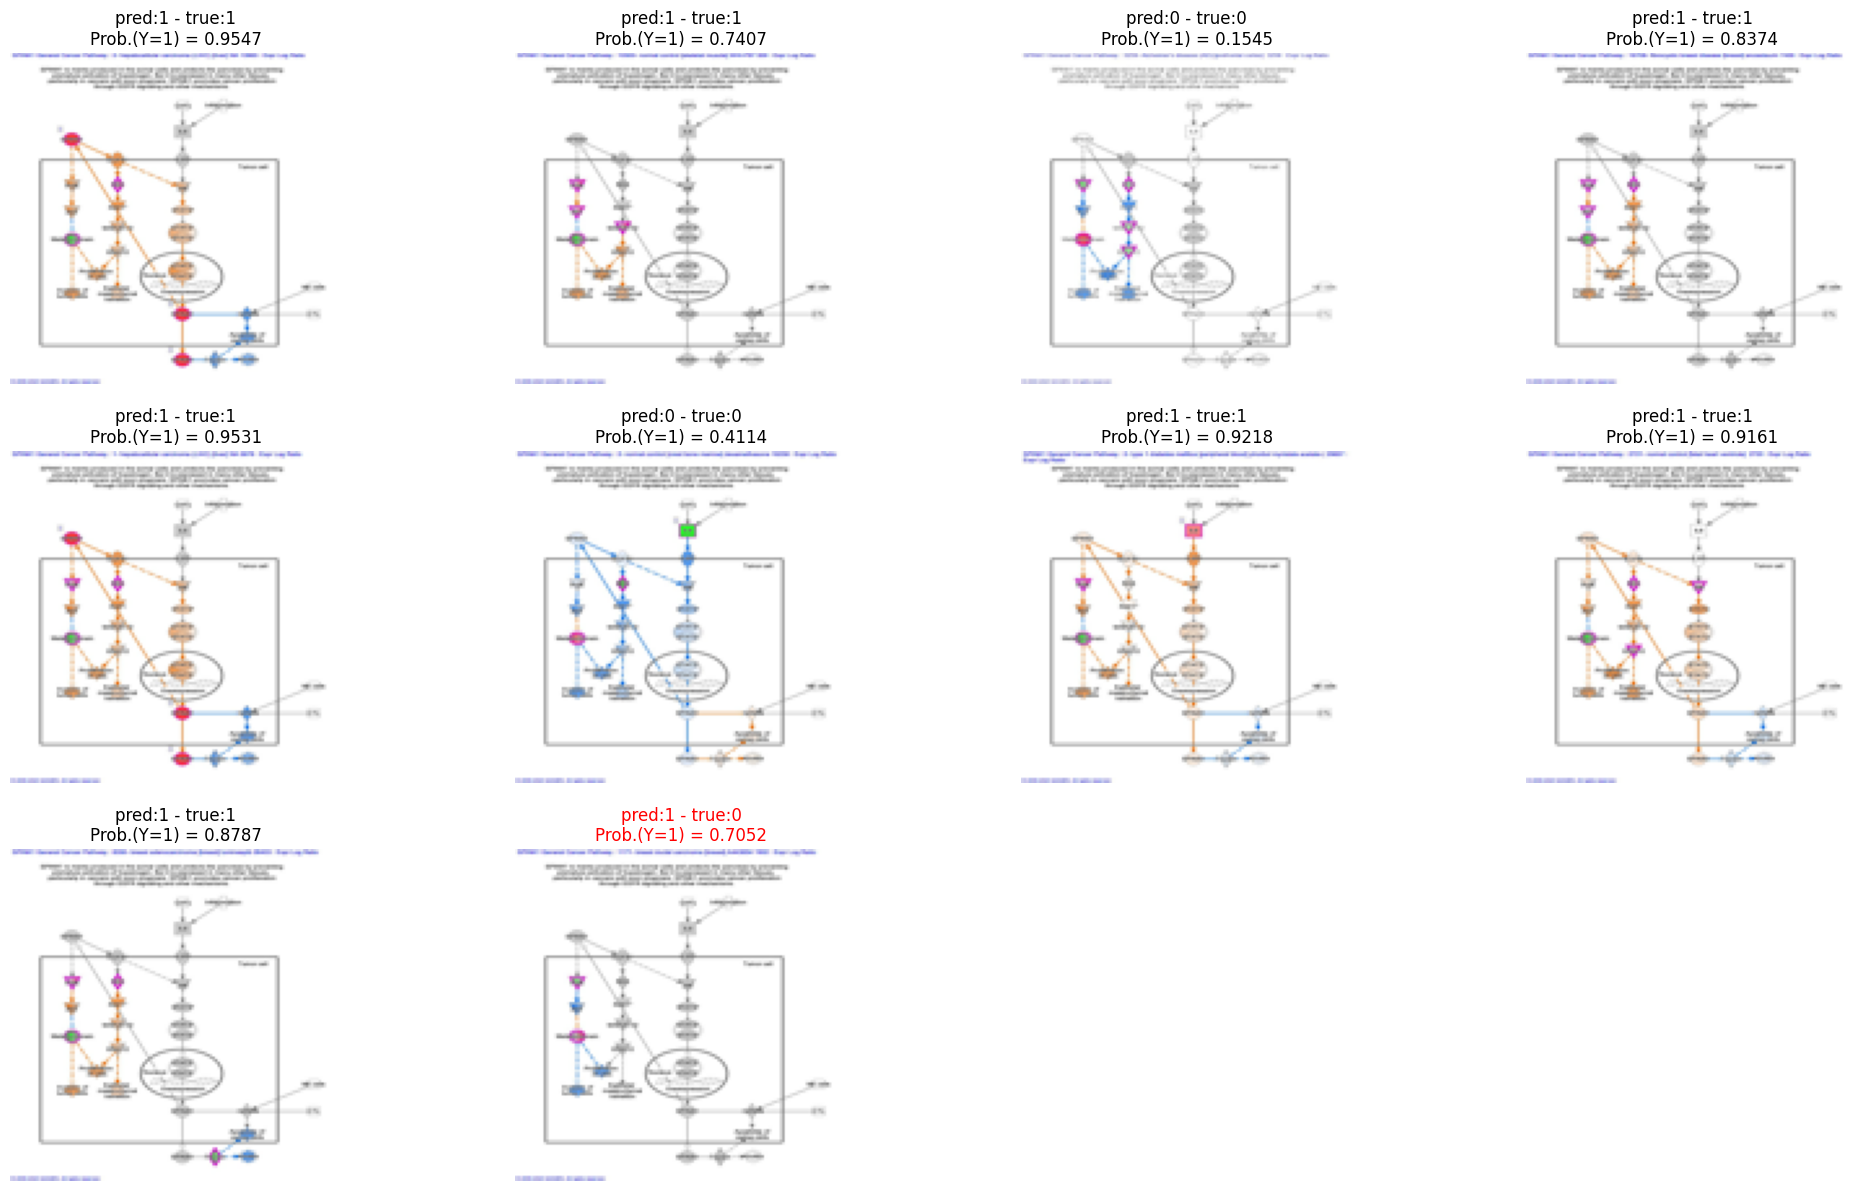

In [41]:
# Output the data images, predicted labels, ground truth labels, and prediction probabilities
plt.figure(figsize = (25, 25))
for i in range(n_test): # Iterate only up to the number of test samples
    plt.subplot(5, 4, i + 1)
    plt.axis("off")
    if pred[i] == true[i]:
        plt.title("pred:"+str(pred[i].astype(np.uint8))+' - '+"true:"+str(true[i].astype(np.uint8))+'\n'+'Prob.(Y=1) = %.4f' % (prob[i]))
    else:
        plt.title("pred:"+str(pred[i].astype(np.uint8))+' - '+"true:"+str(true[i].astype(np.uint8))+'\n'+'Prob.(Y=1) = %.4f' % (prob[i]), color = "red") # If the classification is incorrect, write it in red.

    tmp = test_x[i][0].to('cpu').detach().numpy().copy()
    tmp = tmp.transpose(1, 2, 0)
    img_pil = Image.fromarray((tmp*255).astype(np.uint8))
    plt.imshow(img_pil)

In [42]:
#Summarize correct and incorrect answers in a 2×2 matrix
cmat = confusion_matrix(true, pred)
print(cmat)

#Calculation of Sensitivity and Specificity
tn, fp, fn, tp = cmat.flatten()

acc = round((tp+tn)/(tp+tn+fp+fn),4)
sen = round(tp/(tp+fn),4)
spe = round(tn/(tn+fp),4)
ppv = round(tp/(tp+fp),4)
npv = round(tn/(tn+fn),4)
print("acc=",acc,"sen=",sen," ,spe=",spe," ,ppv=",ppv," ,npv=",npv)

[[2 1]
 [0 7]]
acc= 0.9 sen= 1.0  ,spe= 0.6667  ,ppv= 0.875  ,npv= 1.0


Cutoff-value: 0.7407 Sensitivity: 1.0 Specificity:  1.0


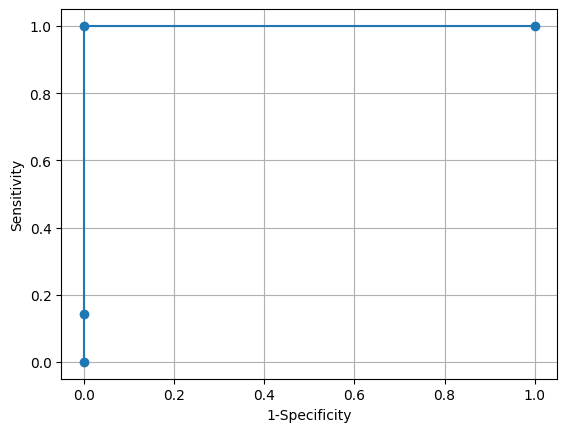

In [43]:
#ROC curve

fpr, tpr, thresholds = roc_curve(true, prob)
plt.plot(fpr, tpr, marker='o')
plt.xlabel('1-Specificity')
plt.ylabel('Sensitivity')
plt.grid()
#plt.savefig(path+'/roc_curve.png')

Youden_index = tpr-fpr
index = np.where(Youden_index==max(Youden_index))[0][0]

cutoff = thresholds[index]
sensitivity = tpr[index]
specificity = 1 - fpr[index]
print("Cutoff-value:",round(cutoff,4),"Sensitivity:",round(sensitivity,4),"Specificity: ",round(specificity,4))